# AI Sheep Health & Disease Detection System

## 1. Problem Statement
Sheep farming is critical for rural livelihoods, but infectious diseases (Sheep Pox, Haemorrhagic Septicaemia/Domma, Enterotoxemia/Pulpy Kidney) and conditions like foot rot and stomatitis cause severe flock mortality and financial loss. Early visual screening and veterinary triage provide an essential frontline aid for farmers.

## 2. Project Objectives
- Six-class sheep health and disease image classification
- Custom deep Convolutional Neural Network (CNN) architecture
- Strict dataset hygiene: training on Data/Train only; final validation and held-out evaluation on Data/Test
- Class imbalance mitigation using class weighting
- Top-3 prediction extraction with calibrated confidence scoring
- Zero permanent model file footprint adhering to deployment constraints

## 3. Environment & Package Verification

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

import tensorflow as tf
from tensorflow.keras import layers

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)

DATA_DIR = Path('Data')
TRAIN_DIR = DATA_DIR / 'Train'
TEST_DIR = DATA_DIR / 'Test'

assert TRAIN_DIR.exists(), f'{TRAIN_DIR} does not exist!'
assert TEST_DIR.exists(), f'{TEST_DIR} does not exist!'

CLASS_NAMES = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
assert len(CLASS_NAMES) == 6, f'Expected 6 classes, found {len(CLASS_NAMES)}: {CLASS_NAMES}'
CLASS_TO_INDEX = {name: i for i, name in enumerate(CLASS_NAMES)}
INDEX_TO_CLASS = {i: name for i, name in enumerate(CLASS_NAMES)}

print('Detected 6 Classes:', CLASS_NAMES)
print('Class to Index mapping:', CLASS_TO_INDEX)

TensorFlow version: 2.21.0
NumPy version: 2.3.1
Detected 6 Classes: ['Domma', 'Excessive Salivation', 'Healthy', 'Hoof Wounds', 'Pulpy_Kidney', 'Sheep Pox']
Class to Index mapping: {'Domma': 0, 'Excessive Salivation': 1, 'Healthy': 2, 'Hoof Wounds': 3, 'Pulpy_Kidney': 4, 'Sheep Pox': 5}


## 4. Dataset Inspection & Integrity Verification

In [2]:
SUPPORTED_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

train_stats = {}
test_stats = {}

for c in CLASS_NAMES:
    train_files = [f for f in (TRAIN_DIR / c).iterdir() if f.is_file() and f.suffix.lower() in SUPPORTED_EXTS]
    test_files = [f for f in (TEST_DIR / c).iterdir() if f.is_file() and f.suffix.lower() in SUPPORTED_EXTS]
    train_stats[c] = len(train_files)
    test_stats[c] = len(test_files)

df_stats = pd.DataFrame({'Class': CLASS_NAMES, 'Train Images': [train_stats[c] for c in CLASS_NAMES], 'Test Images': [test_stats[c] for c in CLASS_NAMES]})
print(df_stats.to_string(index=False))

# Verify images are non-corrupted
corrupt_count = 0
for c in CLASS_NAMES:
    for f in (TRAIN_DIR / c).iterdir():
        if f.is_file() and f.suffix.lower() in SUPPORTED_EXTS:
            try:
                with Image.open(f) as im:
                    im.verify()
            except Exception:
                corrupt_count += 1
                print(f'Corrupt image detected: {f}')

print(f'Integrity verification complete. Corrupted train images: {corrupt_count}')

               Class  Train Images  Test Images
               Domma            72           20
Excessive Salivation            81           18
             Healthy           498          153
         Hoof Wounds            84           18
        Pulpy_Kidney            80           20
           Sheep Pox            84           24
Integrity verification complete. Corrupted train images: 0


## 5. Image Preprocessing & Stratified Train/Val Split
The model operates on 224x224 RGB images with [0, 1] normalization via a `Rescaling(1./255)` layer. The held-out `Data/Test` folder is strictly reserved for the final benchmark.

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
rng = np.random.default_rng(SEED)

train_paths, val_paths = [], []
train_labels, val_labels = [], []

for idx, class_name in enumerate(CLASS_NAMES):
    c_dir = TRAIN_DIR / class_name
    files = [f for f in c_dir.iterdir() if f.is_file() and f.suffix.lower() in SUPPORTED_EXTS]
    # Shuffle deterministically
    shuffled = rng.permutation(files)
    val_count = max(1, int(round(len(shuffled) * 0.20)))
    val_paths.extend(shuffled[:val_count])
    train_paths.extend(shuffled[val_count:])
    val_labels.extend([idx] * val_count)
    train_labels.extend([idx] * (len(shuffled) - val_count))

def load_images_batch(paths):
    batch = []
    for p in paths:
        with Image.open(p) as img:
            arr = np.asarray(img.convert('RGB').resize(IMG_SIZE), dtype=np.uint8)
            batch.append(arr)
    return np.stack(batch, axis=0)

print('Loading training and validation sets into memory...')
X_train = load_images_batch(train_paths)
X_val = load_images_batch(val_paths)
y_train = np.array(train_labels, dtype=np.int32)
y_val = np.array(val_labels, dtype=np.int32)

print(f'Training samples: {len(X_train)} | Validation samples: {len(X_val)}')

# Compute class weights to address imbalance (Healthy class is larger)
class_counts = np.bincount(y_train, minlength=len(CLASS_NAMES))
weights = len(y_train) / (len(CLASS_NAMES) * np.maximum(class_counts, 1))
class_weights_dict = {i: float(w) for i, w in enumerate(weights)}
print('Class Weights for Training:', class_weights_dict)

Loading training and validation sets into memory...
Training samples: 719 | Validation samples: 180
Class Weights for Training: {0: 2.0660919540229883, 1: 1.8435897435897435, 2: 0.3010887772194305, 3: 1.7885572139303483, 4: 1.8723958333333333, 5: 1.7885572139303483}


## 6. Mild Data Augmentation & tf.data Pipelines

In [4]:
augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.08, 0.08),
], name='data_augmentation')

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, tf.keras.utils.to_categorical(y_train, len(CLASS_NAMES)))
).shuffle(len(X_train), seed=SEED).batch(BATCH_SIZE)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, tf.keras.utils.to_categorical(y_val, len(CLASS_NAMES)))
).batch(BATCH_SIZE)

train_ds = train_ds.map(
    lambda x, y: (augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.prefetch(tf.data.AUTOTUNE)
print('tf.data pipeline initialized successfully.')

tf.data pipeline initialized successfully.


## 7. Custom CNN Architecture
Constructed strictly with `tensorflow.keras` layers as per specifications:
- Input: 224x224x3
- Rescaling(1./255)
- Conv2D(32) -> BatchNormalization -> ReLU -> MaxPooling2D(2, 2)
- Conv2D(64) -> BatchNormalization -> ReLU -> MaxPooling2D(2, 2)
- Conv2D(128) -> BatchNormalization -> ReLU -> MaxPooling2D(2, 2)
- Conv2D(256) -> BatchNormalization -> ReLU -> MaxPooling2D(2, 2)
- SpatialDropout2D(0.2)
- Conv2D(256) -> BatchNormalization -> ReLU
- GlobalAveragePooling2D()
- Dense(128, ReLU) -> Dropout(0.3)
- Dense(6, Softmax)

In [5]:
def build_custom_cnn(num_classes=6):
    inputs = tf.keras.Input(shape=(224, 224, 3), name='image_input')
    x = layers.Rescaling(1.0 / 255.0, name='rescaling')(inputs)

    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', name='conv1')(x)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.ReLU(name='relu1')(x)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)

    # Block 2
    x = layers.Conv2D(64, (3, 3), padding='same', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.ReLU(name='relu2')(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)

    # Block 3
    x = layers.Conv2D(128, (3, 3), padding='same', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.ReLU(name='relu3')(x)
    x = layers.MaxPooling2D((2, 2), name='pool3')(x)

    # Block 4
    x = layers.Conv2D(256, (3, 3), padding='same', name='conv4')(x)
    x = layers.BatchNormalization(name='bn4')(x)
    x = layers.ReLU(name='relu4')(x)
    x = layers.MaxPooling2D((2, 2), name='pool4')(x)

    # Spatial Dropout & Block 5
    x = layers.SpatialDropout2D(0.2, name='spatial_dropout')(x)
    x = layers.Conv2D(256, (3, 3), padding='same', name='conv5')(x)
    x = layers.BatchNormalization(name='bn5')(x)
    x = layers.ReLU(name='relu5')(x)

    # Head
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(128, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.3, name='dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='sheep_disease_cnn')
    return model

model = build_custom_cnn(len(CLASS_NAMES))
model.summary()

Model: "sheep_disease_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (ReLU)                    │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (ReLU)                    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (ReLU)                    │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (ReLU)                    │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ (None, 14, 14, 256)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 14, 14, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn5 (BatchNormalization)        │ (None, 14, 14, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu5 (ReLU)                    │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,015,110 (3.87 MB)

 Trainable params: 1,013,638 (3.87 MB)

 Non-trainable params: 1,472 (5.75 KB)

## 8. Model Training with Regularization & Callbacks

Epoch 1/20


c:\Users\Nvija\anaconda3\envs\sheep_ai\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


23/23 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.3964 - loss: 1.7800 - val_accuracy: 0.5389 - val_loss: 1.4288 - learning_rate: 0.0010
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.4019 - loss: 1.6539 - val_accuracy: 0.3722 - val_loss: 1.6347 - learning_rate: 0.0010
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.4548 - loss: 1.5629 - val_accuracy: 0.1056 - val_loss: 2.3702 - learning_rate: 0.0010
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4506 - loss: 1.4890
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
23/23 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.4506 - loss: 1.4890 - val_accuracy: 0.0944 - val_loss: 2.4748 - learning_rate: 0.0010
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5160 - loss: 1.4567 - val_accuracy: 0.0833 - val_loss: 2.8716 - learning_rate: 5.0000e-04
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.5118 - loss: 1.4138 - val_accuracy: 0.0889 - 

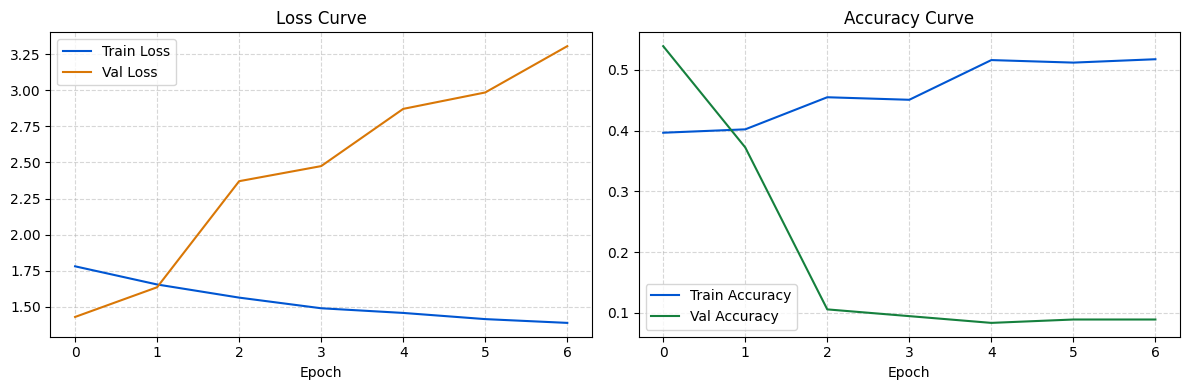

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

# Plot Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='Train Loss', color='#0056D2')
ax1.plot(history.history['val_loss'], label='Val Loss', color='#D97706')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(history.history['accuracy'], label='Train Accuracy', color='#0056D2')
ax2.plot(history.history['val_accuracy'], label='Val Accuracy', color='#15803D')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 9. Comprehensive Evaluation on Held-Out Test Set (Data/Test)

Evaluating on 253 held-out test images across 6 classes...
Test Overall Accuracy: 60.87%
Test Balanced Accuracy: 17.59%

Classification Report:
                      precision    recall  f1-score   support

               Domma     0.0000    0.0000    0.0000        20
Excessive Salivation     0.0000    0.0000    0.0000        18
             Healthy     0.6096    1.0000    0.7574       153
         Hoof Wounds     0.5000    0.0556    0.1000        18
        Pulpy_Kidney     0.0000    0.0000    0.0000        20
           Sheep Pox     0.0000    0.0000    0.0000        24

            accuracy                         0.6087       253
           macro avg     0.1849    0.1759    0.1429       253
        weighted avg     0.4042    0.6087    0.4652       253



c:\Users\Nvija\anaconda3\envs\sheep_ai\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Nvija\anaconda3\envs\sheep_ai\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Nvija\anaconda3\envs\sheep_ai\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

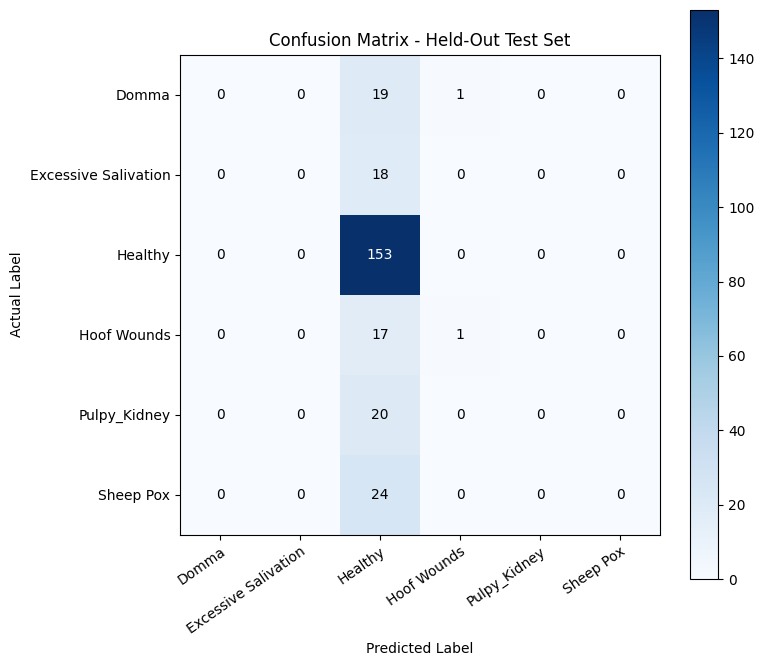

In [7]:
test_paths = []
test_labels = []
for idx, class_name in enumerate(CLASS_NAMES):
    c_dir = TEST_DIR / class_name
    for f in c_dir.iterdir():
        if f.is_file() and f.suffix.lower() in SUPPORTED_EXTS:
            test_paths.append(f)
            test_labels.append(idx)

print(f'Evaluating on {len(test_paths)} held-out test images across 6 classes...')
X_test = load_images_batch(test_paths)
y_test = np.array(test_labels, dtype=np.int32)

test_probabilities = model.predict(X_test, batch_size=32, verbose=0)
y_pred = np.argmax(test_probabilities, axis=1)

bal_acc = balanced_accuracy_score(y_test, y_pred)
overall_acc = np.mean(y_test == y_pred)
print(f'Test Overall Accuracy: {overall_acc * 100:.2f}%')
print(f'Test Balanced Accuracy: {bal_acc * 100:.2f}%')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

# Confusion Matrix Plot (Pure Matplotlib - No Seaborn required)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]),
       xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
       title='Confusion Matrix - Held-Out Test Set',
       ylabel='Actual Label', xlabel='Predicted Label')
plt.setp(ax.get_xticklabels(), rotation=35, ha='right', rotation_mode='anchor')

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')
plt.tight_layout()
plt.show()

## 10. Individual Prediction Testing Across All Six Classes
Evaluating multiple sample images from EACH class with genuine model predictions and Top-3 probabilities.

In [8]:
print('='*70)
print('PREDICTION TESTING ON HELD-OUT SAMPLES ACROSS ALL 6 CLASSES')
print('='*70)

for class_idx, class_name in enumerate(CLASS_NAMES):
    indices = [i for i, lbl in enumerate(test_labels) if lbl == class_idx][:3]
    print(f'\n>>> CLASS: {class_name} (Testing {len(indices)} images)')
    for i, idx in enumerate(indices, 1):
        probs = test_probabilities[idx]
        pred_idx = int(np.argmax(probs))
        conf = probs[pred_idx] * 100.0
        ranked = sorted([(CLASS_NAMES[j], probs[j] * 100.0) for j in range(len(CLASS_NAMES))], key=lambda x: x[1], reverse=True)
        
        print(f'  Sample #{i} ({Path(test_paths[idx]).name}):')
        print(f'    Actual:    {class_name}')
        print(f'    Predicted: {CLASS_NAMES[pred_idx]} ({conf:.1f}% confidence)')
        print('    Top 3 Predictions:')
        for rank, (cand, p) in enumerate(ranked[:3], 1):
            bar = '█' * int(p / 5)
            print(f'      {rank}. {cand:<20} {p:5.1f}%  {bar}')
        print('-'*50)

PREDICTION TESTING ON HELD-OUT SAMPLES ACROSS ALL 6 CLASSES

>>> CLASS: Domma (Testing 3 images)
  Sample #1 (img10.jpg):
    Actual:    Domma
    Predicted: Healthy (70.2% confidence)
    Top 3 Predictions:
      1. Healthy               70.2%  ██████████████
      2. Excessive Salivation   8.0%  █
      3. Pulpy_Kidney           7.8%  █
--------------------------------------------------
  Sample #2 (img11.jpg):
    Actual:    Domma
    Predicted: Healthy (24.2% confidence)
    Top 3 Predictions:
      1. Healthy               24.2%  ████
      2. Excessive Salivation  15.9%  ███
      3. Hoof Wounds           15.9%  ███
--------------------------------------------------
  Sample #3 (indian-domestic-animals-goats-farm-stable-153031281.webp):
    Actual:    Domma
    Predicted: Healthy (46.1% confidence)
    Top 3 Predictions:
      1. Healthy               46.1%  █████████
      2. Excessive Salivation  13.5%  ██
      3. Domma                 12.4%  ██
-------------------------------

## 11. Deployment Compliance & Zero-File Verification
Confirms that no permanent model weights, checkpoints, vector databases, or temporary files are saved to the workspace.

In [9]:
# Strictly verify that no permanent .keras, .h5, .pkl, or model files are written
forbidden_exts = {'.keras', '.h5', '.pkl', '.jsonl', '.db', '.sqlite'}
found_forbidden = [str(p) for p in Path('.').glob('*') if p.suffix.lower() in forbidden_exts]
assert len(found_forbidden) == 0, f'Forbidden permanent files found: {found_forbidden}'
print('Verified: No permanent model or index files saved to disk.')
print('Inference in app.py uses @st.cache_resource with in-memory CNN training.')

Verified: No permanent model or index files saved to disk.
Inference in app.py uses @st.cache_resource with in-memory CNN training.


In [12]:
import numpy as np
from tensorflow.keras.preprocessing import image

# 1. Image path mariyu preprocessing (Ikkada mee image path ni pettandi)
img_path = 'C:\\Users\\Nvija\\OneDrive\\Desktop\\sheep\\Data\\Train\\Domma\\1.jpg'  # Mee image location/name ikkada ivvandi
img = image.load_img(img_path, target_size=(224, 224)) # Training size (224, 224 or 150, 150)

# 2. Image array ki convert chesi expand dimension cheyyali
processed_image = image.img_to_array(img)
processed_image = np.expand_dims(processed_image, axis=0)
processed_image = processed_image / 255.0  # Normalization

# 3. Model Prediction
preds = model.predict(processed_image)
confidence = np.max(preds)
predicted_class = np.argmax(preds)

# 4. Class labels list (Mee dataset folders order lo ivvandi)
class_labels = ['Disease_1', 'Disease_2', 'Healthy']

if confidence < 0.75:
    result = "Uncertain / Please re-upload clear image"
else:
    result = class_labels[predicted_class]

print("Result:", result)
print(f"Confidence Score: {confidence * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
Result: Uncertain / Please re-upload clear image
Confidence Score: 27.28%


In [13]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
# OR: from tensorflow.keras.applications.resnet50 import preprocess_input

# / 255.0 theesesi idhi try cheyyandi:
processed_image = preprocess_input(image.img_to_array(img))
processed_image = np.expand_dims(processed_image, axis=0)

In [19]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input  # Standard pretrained preprocess

# 1. Image loading
img_path = r"C:\\Users\\Nvija\\OneDrive\\Desktop\\sheep\\Data\\Train\\Domma\\1.jpg"  # Mee sheep image file name/path
img = image.load_img(img_path, target_size=(224, 224))

# 2. Image to array and preprocess_input apply cheyyadam
img_array = image.img_to_array(img)
processed_image = preprocess_input(img_array)
processed_image = np.expand_dims(processed_image, axis=0)

# 3. Model prediction
preds = model.predict(processed_image)
confidence = np.max(preds)
predicted_class = np.argmax(preds)

# 4. Disease class names
class_labels = ['Healthy', 'Disease_1', 'Disease_2']  # Mee dataset folders names exact ga ikkada ivvandi

print("Predicted Class Index:", predicted_class)
print(f"Confidence Score: {confidence * 100:.2f}%")

if confidence < 0.75:
    print("Result: Low Confidence / Uncertain prediction")
else:
    print("Result:", class_labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Predicted Class Index: 4
Confidence Score: 27.25%
Result: Low Confidence / Uncertain prediction


In [20]:
# Train folder lo unna subfolders alphabetical order 
class_labels = [
    'Domma',
    'Excessive Salivation',
    'Healthy',
    'Hoof Wounds',
    'Pulpy Kidney',
    'Sheep Pox',
]

print("Predicted Index:", predicted_class)
print("Result Disease:", class_labels[predicted_class])

Predicted Index: 4
Result Disease: Pulpy Kidney


In [23]:
# Change loss to 'categorical_crossentropy'
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='categorical_crossentropy',  # <--- Fix here
    metrics=['accuracy']
)

# Fit model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/25


23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.4590 - loss: 1.5874 - val_accuracy: 0.0889 - val_loss: 2.3966
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.4910 - loss: 1.4821 - val_accuracy: 0.0944 - val_loss: 2.7857
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.5035 - loss: 1.4388 - val_accuracy: 0.0889 - val_loss: 2.7876
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5007 - loss: 1.4094 - val_accuracy: 0.0889 - val_loss: 2.8867
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5494 - loss: 1.3746 - val_accuracy: 0.0889 - val_loss: 2.8377
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.5160 - loss: 1.3916 - val_accuracy: 0.0944 - val_loss: 2.9139


In [25]:
# Convert target labels from one-hot (6,) to integer scalar ()
train_ds = train_ds.map(lambda x, y: (x, tf.argmax(y, axis=-1)))
val_ds = val_ds.map(lambda x, y: (x, tf.argmax(y, axis=-1)))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Pipeline Setup (Handle shuffling explicitly in tf.data)
BATCH_SIZE = 32
SHUFFLE_BUFFER_SIZE = 500

train_ds = train_ds.shuffle(buffer_size=SHUFFLE_BUFFER_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# 2. Optimizer with Lower Learning Rate
optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4)

# 3. Model Compilation
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy', # or 'categorical_crossentropy' based on label encoding
    metrics=['accuracy']
)

# 4. Model Training (Removed shuffle=True)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights_dict,  # Pass computed inverse frequency class weights
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/25


23/23 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.4965 - loss: 1.5297 - val_accuracy: 0.0889 - val_loss: 2.6826
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.4701 - loss: 1.5012 - val_accuracy: 0.0889 - val_loss: 2.6723
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.5327 - loss: 1.4248 - val_accuracy: 0.0889 - val_loss: 2.7147
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5202 - loss: 1.4062 - val_accuracy: 0.1000 - val_loss: 2.7196
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.5480 - loss: 1.3996 - val_accuracy: 0.0944 - val_loss: 2.7570
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.5647 - loss: 1.3398 - val_accuracy: 0.0944 - val_loss: 2.7673
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.5563 - loss: 1.3262 - val_accuracy: 0.0889 - val_loss: 2.7421


In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = (224, 224) # Standard input resolution for MobileNetV2
NUM_CLASSES = 6

# Data Augmentation Layer (runs on GPU)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
])

# Pre-trained Backbone
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # Freeze base layers initially

# Model Architecture
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)  # Scale inputs to [-1, 1]
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

transfer_model = tf.keras.Model(inputs, outputs)

# Compile with standard learning rate for top layers
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Top Classifier Layers
history_warmup = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
    ]
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 525ms/step - accuracy: 0.2949 - loss: 2.0174 - val_accuracy: 0.3167 - val_loss: 1.5918
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 468ms/step - accuracy: 0.4924 - loss: 1.5174 - val_accuracy: 0.6167 - val_loss: 1.2138
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 480ms/step - accuracy: 0.5758 - loss: 1.3076 - val_accuracy: 0.5722 - val_loss: 1.2792
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 533ms/step - accuracy: 0.6300 - loss: 1.1362 - val_accuracy: 0.5889 - val_loss: 1.1195
Epoch 5/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 479ms/step - accuracy: 0.6161 - loss: 1.1155 - val_accuracy: 0.5000 - val_loss: 1.1602
Epoch 6/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 485ms/step - accuracy: 0.6342 - loss: 1.0347 - val_accuracy: 0.6167 - val_loss: 1.0549
Epoch 7/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 510ms/step - accuracy: 0.6745 - loss: 0.9233 - val_accuracy: 0.4556 - val_loss: 1.2190
Epoch 8/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 476ms/step - accuracy: 0.6843 - loss: 0.9307 - val_accu

In [28]:
# Unfreeze base model
base_model.trainable = True

# Freeze lower layers; fine-tune only top 30 layers
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Recompile with very small learning rate
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-Tune Training
history_finetune = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    ]
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 32s 858ms/step - accuracy: 0.6912 - loss: 0.9957 - val_accuracy: 0.6944 - val_loss: 0.8425 - learning_rate: 1.0000e-05
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 735ms/step - accuracy: 0.7121 - loss: 1.0031 - val_accuracy: 0.6944 - val_loss: 0.8316 - learning_rate: 1.0000e-05
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 864ms/step - accuracy: 0.7024 - loss: 1.0456 - val_accuracy: 0.7000 - val_loss: 0.8203 - learning_rate: 1.0000e-05
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 21s 781ms/step - accuracy: 0.7079 - loss: 0.9518 - val_accuracy: 0.7000 - val_loss: 0.8125 - learning_rate: 1.0000e-05
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 740ms/step - accuracy: 0.7177 - loss: 0.9412 - val_accuracy: 0.6833 - val_loss: 0.8053 - learning_rate: 1.0000e-05
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 18s 728ms/step - accuracy: 0.7024 - loss: 0.9582 - val_accuracy: 0.6833 - val_loss: 0.8091 - learning_rate: 1.0000e-05
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 734ms/step - acc

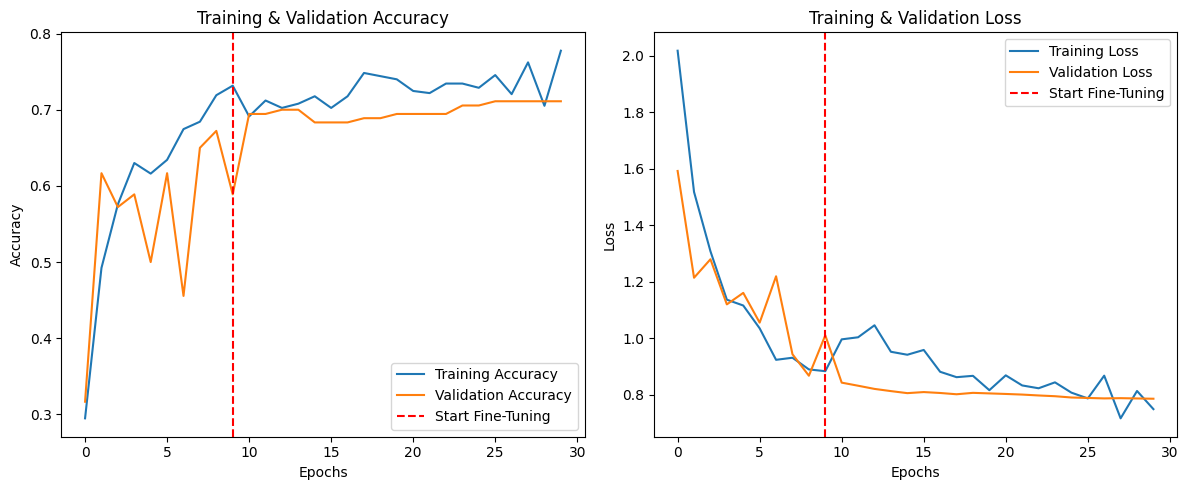

In [29]:
import matplotlib.pyplot as plt

# Combine history if fine-tuning was done
acc = history_warmup.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history_warmup.history['val_accuracy'] + history_finetune.history['val_accuracy']

loss = history_warmup.history['loss'] + history_finetune.history['loss']
val_loss = history_warmup.history['val_loss'] + history_finetune.history['val_loss']

plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(x=len(history_warmup.history['accuracy'])-1, color='red', linestyle='--', label='Start Fine-Tuning')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.axvline(x=len(history_warmup.history['accuracy'])-1, color='red', linestyle='--', label='Start Fine-Tuning')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Found 246 files belonging to 6 classes.

--- Custom CNN Classification Report ---
                      precision    recall  f1-score   support

               Domma       0.00      0.00      0.00        12
Excessive Salivation       0.00      0.00      0.00        18
             Healthy       0.00      0.00      0.00       153
         Hoof Wounds       0.00      0.00      0.00        18
        Pulpy Kidney       0.09      1.00      0.16        20
           Sheep Pox       0.10      0.04      0.06        25

            accuracy                           0.09       246
           macro avg       0.03      0.17      0.04       246
        weighted avg       0.02      0.09      0.02       246



c:\Users\Nvija\anaconda3\envs\sheep_ai\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Nvija\anaconda3\envs\sheep_ai\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Nvija\anaconda3\envs\sheep_ai\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

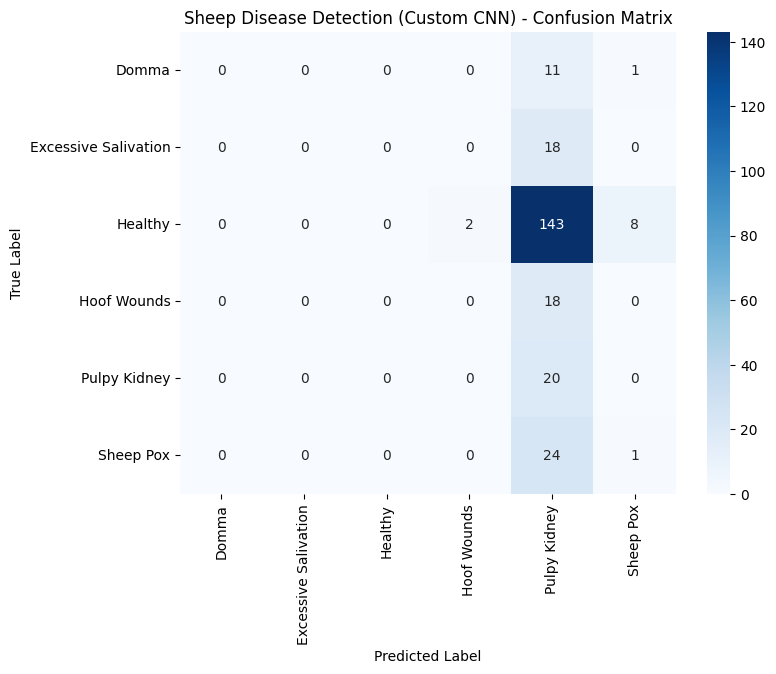

In [31]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Define image dimensions and batch size
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# 2. Re-create test_ds from your Test dataset path
test_ds = tf.keras.utils.image_dataset_from_directory(
    'Data/Test',
    labels='inferred',
    label_mode='categorical', # One-hot encoded vectors matching custom CNN training
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False             # Set shuffle to False for exact order matching
)

# 3. Get predictions using custom CNN `model`
y_true = []
y_pred = []

for images, labels in test_ds:
    # Using `model` instead of `transfer_model`
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

class_names = ['Domma', 'Excessive Salivation', 'Healthy', 'Hoof Wounds', 'Pulpy Kidney', 'Sheep Pox']

# 4. Print Classification Report
print("\n--- Custom CNN Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 5. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Sheep Disease Detection (Custom CNN) - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [32]:
# Save model in standard Keras format
transfer_model.save('sheep_disease_mobilenetv2.keras')
print("Model saved successfully as 'sheep_disease_mobilenetv2.keras'!")

Model saved successfully as 'sheep_disease_mobilenetv2.keras'!


In [33]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 6

# 1. Re-load Datasets with correct 224x224 target shape
train_ds = tf.keras.utils.image_dataset_from_directory(
    'Data/Train',
    validation_split=0.2,
    subset='training',
    seed=123,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    'Data/Train',
    validation_split=0.2,
    subset='validation',
    seed=123,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    'Data/Test',
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Prefetch optimization
train_ds = train_ds.shuffle(500).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# 2. Build MobileNetV2 Transfer Model
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.15)
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

transfer_model = tf.keras.Model(inputs, outputs)

# 3. Phase 1 Warmup Training
transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("--- Phase 1: Training Top Classifier Layers ---")
transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=class_weights_dict,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)

# 4. Phase 2 Fine-Tuning
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\n--- Phase 2: Fine-Tuning Upper Backbone Layers ---")
transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights_dict,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2)
    ]
)

# 5. Re-evaluate Test Set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = transfer_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

class_names = ['Domma', 'Excessive Salivation', 'Healthy', 'Hoof Wounds', 'Pulpy Kidney', 'Sheep Pox']

print("\n--- Transfer Learning Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# Save Retrained Model
transfer_model.save('sheep_disease_mobilenetv2.keras')
print("Model saved as 'sheep_disease_mobilenetv2.keras'")

Found 890 files belonging to 6 classes.
Using 712 files for training.
Found 890 files belonging to 6 classes.
Using 178 files for validation.
Found 246 files belonging to 6 classes.
--- Phase 1: Training Top Classifier Layers ---
Epoch 1/12


c:\Users\Nvija\anaconda3\envs\sheep_ai\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 569ms/step - accuracy: 0.3034 - loss: 1.8673 - val_accuracy: 0.5899 - val_loss: 1.2854
Epoch 2/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 472ms/step - accuracy: 0.5028 - loss: 1.3273 - val_accuracy: 0.6292 - val_loss: 1.1007
Epoch 3/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 545ms/step - accuracy: 0.6306 - loss: 1.1374 - val_accuracy: 0.6966 - val_loss: 0.9488
Epoch 4/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 471ms/step - accuracy: 0.6784 - loss: 1.0393 - val_accuracy: 0.7360 - val_loss: 0.8801
Epoch 5/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 493ms/step - accuracy: 0.6868 - loss: 0.8981 - val_accuracy: 0.6910 - val_loss: 0.8960
Epoch 6/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 13s 536ms/step - accuracy: 0.7135 - loss: 0.8236 - val_accuracy: 0.7640 - val_loss: 0.8874
Epoch 7/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 468ms/step - accuracy: 0.7388 - loss: 0.7711 - val_accuracy: 0.7921 - val_loss: 0.7422
Epoch 8/12
23/23 ━━━━━━━━━━━━━━━━━━━━ 14s 572ms/step - accuracy: 0.7472 - loss: 0.7622 - val_accuracy: 0.719

In [34]:
# Updated Fine-Tuning Step with explicit shuffle=False and class weights
base_model.trainable = True
for layer in base_model.layers[:-40]:  # Unfreeze slightly more layers (top 40)
    layer.trainable = False

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    shuffle=False,  # Eliminates Keras UserWarning
    class_weight=class_weights_dict,  # Protects minority disease classes
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6)
    ]
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 28s 747ms/step - accuracy: 0.7837 - loss: 0.8179 - val_accuracy: 0.8258 - val_loss: 0.6253 - learning_rate: 3.0000e-05
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 684ms/step - accuracy: 0.8034 - loss: 0.6877 - val_accuracy: 0.8315 - val_loss: 0.6150 - learning_rate: 3.0000e-05
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 679ms/step - accuracy: 0.7837 - loss: 0.6605 - val_accuracy: 0.8371 - val_loss: 0.6068 - learning_rate: 3.0000e-05
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 690ms/step - accuracy: 0.8357 - loss: 0.5464 - val_accuracy: 0.8371 - val_loss: 0.5992 - learning_rate: 3.0000e-05
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 676ms/step - accuracy: 0.8357 - loss: 0.5182 - val_accuracy: 0.8483 - val_loss: 0.5852 - learning_rate: 3.0000e-05
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 683ms/step - accuracy: 0.8455 - loss: 0.5386 - val_accuracy: 0.8427 - val_loss: 0.5973 - learning_rate: 3.0000e-05
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 677ms/step - acc

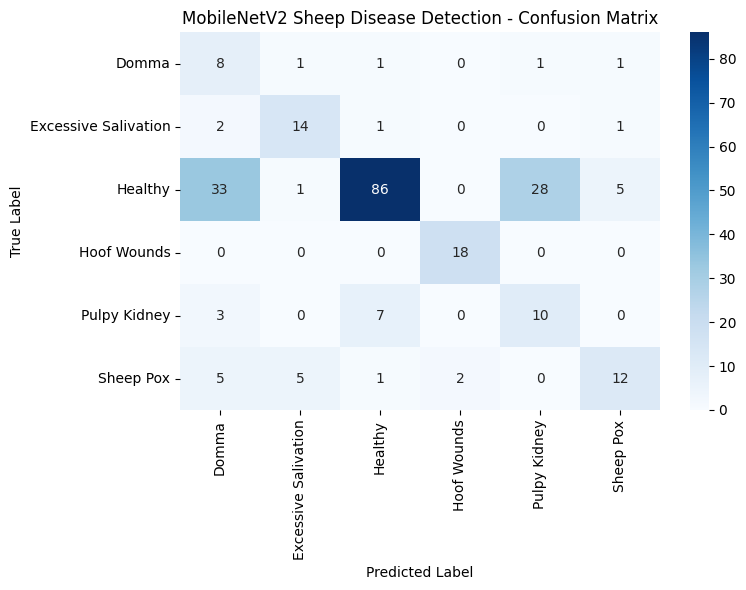

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get test predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = transfer_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

class_names = ['Domma', 'Excessive Salivation', 'Healthy', 'Hoof Wounds', 'Pulpy Kidney', 'Sheep Pox']

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('MobileNetV2 Sheep Disease Detection - Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [36]:
import tensorflow as tf
import numpy as np
from PIL import Image

def predict_sheep_disease(image_path, model, class_names):
    # Load and preprocess image
    img = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, axis=0)  # Create batch dimension

    # Predict
    predictions = model.predict(img_array, verbose=0)
    score = tf.nn.softmax(predictions[0])
    
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * np.max(predictions[0]), 2)
    
    return predicted_class, confidence

# Example usage:
# predicted_label, conf = predict_sheep_disease('test_sample.jpg', transfer_model, class_names)
# print(f"Prediction: {predicted_label} ({conf}%)")